Setup

In [1]:
import os
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)

from sasviya.ml.linear_model import (
    LinearRegression as SASLinearRegression,
    Ridge as SASRidge,
    Lasso as SASLasso,
)

from sasviya.ml.tree import (
    ForestRegressor as SASForestRegressor,
)

warnings.filterwarnings("ignore")

np.random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# If you store the exported CSVs in a different folder, update these paths.
TRAIN_PATH = Path("train.csv")
TEST_PATH = Path("test.csv")

assert TRAIN_PATH.exists(), f"Missing file: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Missing file: {TEST_PATH}"

print("Train path:", TRAIN_PATH.resolve())
print("Test path :", TEST_PATH.resolve())


Train path: /workspaces/myfolder/train.csv
Test path : /workspaces/myfolder/test.csv


Load the Data


In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())
display(test.head())


Train shape: (127802, 45)
Test shape : (14200, 42)


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ADMIT_DATE,DISCHARGE_DATE,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,ORDER_TOTAL_CHARGES,GENDER,ZIP,STATECODE,CITY,COUNTY_NAME,X,Y,REGION,RACE_CD,PATIENT_AGE,DIAGNOSIS_GROUP,ICD9_TARGET,MS_DRG_CODE,MS_DRG_DESC,DRG_APR_CODE,DRG_APR_DESC,DRG_APR_SEVERITY,DIAGNOSIS_SUBCAT_CODE,DIAGNOSIS_SUBCAT_DESC,DIAGNOSIS_ICD_CODE,DIAGNOSIS_LONG_DESC,PROCEDURE_SUBCAT_CODE,PROCEDURE_SUBCAT_DESC,PROCEDURE_ICD_CODE,PROCEDURE_LONG_DESC,DX_CODE,DX_GROUP,OPERATION_COUNT,HOSPITAL,ADMIT_MTH,ADMIT_LOS,NUM_VISITS
0,105256104,9921916104,275709,15OCT2011,27OCT2011,9,HEART,"ROUTINE DSCHG, HOME",Y,0,330013,1,16997,M,33194,FL,Miami,Miami-Dade,-80.391867,25.758515,Region 11,White,83,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.33,ACUTE ON CHRONIC DIASTOLIC HEART FAILURE,99,OTHER NONOPERATIVE PROCE,99.61,ATRIAL CARDIOVERSION,42833,Congestive heart failure; nonhypertensive [108.],1,Hosp 33,10,12,2
1,105256105,9921916105,275709,15OCT2011,27OCT2011,9,HEART,"ROUTINE DSCHG, HOME",Y,0,7003,1,16997,F,33194,FL,Miami,Miami-Dade,-80.391867,25.758515,Region 3,White,88,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.33,ACUTE ON CHRONIC DIASTOLIC HEART FAILURE,99,OTHER NONOPERATIVE PROCE,99.61,ATRIAL CARDIOVERSION,42833,Congestive heart failure; nonhypertensive [108.],0,Hosp 7,10,12,6
2,105256106,9921916106,284130,25NOV2011,27NOV2011,0,HEART,"ROUTINE DSCHG, HOME",Y,2,3002,1,18665,F,33194,FL,Miami,Miami-Dade,-80.391867,25.758515,Region 1,White,80,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.23,ACUTE ON CHRONIC SYSTOLIC HEART FAILURE,.,NaN,.,NaN,42823,Congestive heart failure; nonhypertensive [108.],0,Hosp 3,11,2,1
3,105256107,9921916107,284130,25NOV2011,27NOV2011,0,HEART,"ROUTINE DSCHG, HOME",Y,2,21008,1,18665,F,33194,FL,Miami,Miami-Dade,-80.391867,25.758515,Region 7,White,76,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.23,ACUTE ON CHRONIC SYSTOLIC HEART FAILURE,.,NaN,.,NaN,42823,Congestive heart failure; nonhypertensive [108.],1,Hosp 21,11,2,5
4,105256108,9921916108,287656,15DEC2011,17DEC2011,0,HEART,"ROUTINE DSCHG, HOME",Y,0,370015,1,22835,M,33194,FL,Miami,Miami-Dade,-80.391867,25.758515,Region 11,White,71,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.33,ACUTE ON CHRONIC DIASTOLIC HEART FAILURE,88,OTHER DIAGNOSTIC RADIOLO,88.72,DIAGNOSTIC ULTRASOUND OF HEART,42833,Congestive heart failure; nonhypertensive [108.],0,Hosp 37,12,2,2


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,ORDER_TOTAL_CHARGES,GENDER,ZIP,STATECODE,CITY,COUNTY_NAME,X,Y,REGION,RACE_CD,PATIENT_AGE,DIAGNOSIS_GROUP,ICD9_TARGET,MS_DRG_CODE,MS_DRG_DESC,DRG_APR_CODE,DRG_APR_DESC,DRG_APR_SEVERITY,DIAGNOSIS_SUBCAT_CODE,DIAGNOSIS_SUBCAT_DESC,DIAGNOSIS_ICD_CODE,DIAGNOSIS_LONG_DESC,PROCEDURE_SUBCAT_CODE,PROCEDURE_SUBCAT_DESC,PROCEDURE_ICD_CODE,PROCEDURE_LONG_DESC,DX_CODE,DX_GROUP,OPERATION_COUNT,HOSPITAL,ADMIT_MTH,NUM_VISITS
0,105256127,9921916127,220194,0,TRANSPLANT,"ROUTINE DSCHG, HOME",Y,1,10004,1,31013,F,33194,FL,Miami,Miami-Dade,-80.391867,25.758515,Region 3,White,78,AMI,1,237,MAJOR CARDIOVASC PROCEDURES W MCC OR THORACIC ...,139,OTHER PNEUMONIA,3,482,OTHER BACTERIAL PNEUMONI,482.9,BACTERIAL PNEUMONIA UNSPECIFIED,38,"INCISION, EXCISION, AND",38.91,ARTERIAL CATHETERIZATION,4829,Pneumonia (except that caused by TB or STD) [1...,1,Hosp 10,5,2
1,105256137,9921916137,283122,0,ONCOLOGY,"ROUTINE DSCHG, HOME",Y,0,350014,1,34511,M,33196,FL,Miami,Miami-Dade,-80.481360,25.651234,Region 11,White,74,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.0,CONGESTIVE HEART FAILURE UNSPECIFIED,88,OTHER DIAGNOSTIC RADIOLO,88.72,DIAGNOSTIC ULTRASOUND OF HEART,4280,Congestive heart failure; nonhypertensive [108.],1,Hosp 35,7,7
2,105256138,9921916138,283122,0,ONCOLOGY,"ROUTINE DSCHG, HOME",Y,0,14006,1,34511,M,33196,FL,Miami,Miami-Dade,-80.481360,25.651234,Region 5,White,74,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.0,CONGESTIVE HEART FAILURE UNSPECIFIED,88,OTHER DIAGNOSTIC RADIOLO,88.72,DIAGNOSTIC ULTRASOUND OF HEART,4280,Congestive heart failure; nonhypertensive [108.],0,Hosp 14,7,0
3,105256139,9921916139,262051,0,HEART,"ROUTINE DSCHG, HOME",Y,0,14006,1,26463,F,33306,FL,Fort Lauderdale,Broward,-80.110875,26.163196,Region 5,Others,86,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,3,428,HEART FAILURE,428.0,CONGESTIVE HEART FAILURE UNSPECIFIED,88,OTHER DIAGNOSTIC RADIOLO,88.72,DIAGNOSTIC ULTRASOUND OF HEART,4280,Congestive heart failure; nonhypertensive [108.],0,Hosp 14,10,0
4,105256195,9921916195,296744,1,HEART,"ROUTINE DSCHG, HOME",Y,2,19008,1,30341,F,33308,FL,Fort Lauderdale,Broward,-80.109298,26.189201,Region 6,White,96,CHF,1,293,HEART FAILURE & SHOCK W/O CC/MCC,191,CARDIAC CATHETERIZATION W CIRC DISORD EXC ISCH...,3,428,HEART FAILURE,428.0,CONGESTIVE HEART FAILURE UNSPECIFIED,.,NaN,.,NaN,4280,Congestive heart failure; nonhypertensive [108.],1,Hosp 19,9,0


Check for Missing Values

In [4]:
def basic_report(df: pd.DataFrame, name: str) -> None:
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("\nData types:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing values:")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing[missing > 0].to_frame("missing_count"))
    print("\nDuplicate rows:", df.duplicated().sum())

basic_report(train, "Train")
basic_report(test, "Test")


--- Train ---
Shape: (127802, 45)

Data types:


,dtype
ENCOUNTER_KEY,int64
PATIENT_NUMBER,int64
DOCTOR,int64
ADMIT_DATE,object
DISCHARGE_DATE,object
ICU_DAYS,int64
DEPARTMENT,object
DISCHARGED_TO,object
STANDARD_ORDERS_USED,object
NUM_CHRONIC_COND,object



Missing values:


,missing_count
PROCEDURE_LONG_DESC,40876
PROCEDURE_SUBCAT_DESC,40876



Duplicate rows: 0
--- Test ---
Shape: (14200, 42)

Data types:


,dtype
ENCOUNTER_KEY,int64
PATIENT_NUMBER,int64
DOCTOR,int64
ICU_DAYS,int64
DEPARTMENT,object
DISCHARGED_TO,object
STANDARD_ORDERS_USED,object
NUM_CHRONIC_COND,object
DISCH_NURSE_ID,int64
ORDER_SET_USED,int64



Missing values:


,missing_count
PROCEDURE_SUBCAT_DESC,4468
PROCEDURE_LONG_DESC,4468



Duplicate rows: 0


In [5]:
def invalid_value_checks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform basic data quality checks on numeric variables.
    Returns a summary table containing the number and percentage
    of invalid observations.
    """

    checks = []

    numeric_cols = [
        "PATIENT_AGE",
        "ICU_DAYS",
        "OPERATION_COUNT",
        "NUM_CHRONIC_COND",
        "NUM_VISITS",
        "ORDER_TOTAL_CHARGES",
        "ADMIT_LOS",
    ]

    temp = df.copy()

    for col in numeric_cols:
        if col in temp.columns:
            temp[col] = pd.to_numeric(temp[col], errors="coerce")

    def add_check(description, condition):
        invalid_count = int(condition.sum())
        invalid_pct = round((invalid_count / len(temp)) * 100, 2)

        checks.append({
            "Check": description,
            "Invalid Count": invalid_count,
            "Invalid (%)": invalid_pct,
            "Status": "PASS ✅" if invalid_count == 0 else "REVIEW ⚠️"
        })

    # ----------------------------
    # Age
    # ----------------------------
    if "PATIENT_AGE" in temp.columns:
        add_check("PATIENT_AGE < 0", temp["PATIENT_AGE"] < 0)

    # ----------------------------
    # ICU
    # ----------------------------
    if "ICU_DAYS" in temp.columns:
        add_check("ICU_DAYS < 0", temp["ICU_DAYS"] < 0)

    # ----------------------------
    # Operation Count
    # ----------------------------
    if "OPERATION_COUNT" in temp.columns:
        add_check("OPERATION_COUNT < 0", temp["OPERATION_COUNT"] < 0)

    # ----------------------------
    # Chronic Conditions
    # ----------------------------
    if "NUM_CHRONIC_COND" in temp.columns:
        add_check("NUM_CHRONIC_COND < 0", temp["NUM_CHRONIC_COND"] < 0)

    # ----------------------------
    # Length of Stay
    # ----------------------------
    if "ADMIT_LOS" in temp.columns:
        add_check("ADMIT_LOS < 0", temp["ADMIT_LOS"] < 0)

    # ----------------------------
    # Logical Check
    # ----------------------------
    if {"ICU_DAYS", "ADMIT_LOS"}.issubset(temp.columns):
        add_check(
            "ICU_DAYS > ADMIT_LOS",
            temp["ICU_DAYS"] > temp["ADMIT_LOS"]
        )
    
    # ----------------------------
    # Number of Visits
    # ----------------------------
    if "NUM_VISITS" in temp.columns:
        add_check("NUM_VISITS < 0", temp["NUM_VISITS"] < 0)

    return pd.DataFrame(checks)

results = invalid_value_checks(train)

display(results)

print(f"\nTotal checks performed: {len(results)}")
print(f"Checks passed: {(results['Status'] == 'PASS ✅').sum()}")
print(f"Checks requiring review: {(results['Status'] == 'REVIEW ⚠️').sum()}")

,Check,Invalid Count,Invalid (%),Status
0,PATIENT_AGE < 0,0,0.00,PASS ✅
1,ICU_DAYS < 0,0,0.00,PASS ✅
2,OPERATION_COUNT < 0,0,0.00,PASS ✅
3,NUM_CHRONIC_COND < 0,0,0.00,PASS ✅
4,ADMIT_LOS < 0,0,0.00,PASS ✅
5,ICU_DAYS > ADMIT_LOS,10416,8.15,REVIEW ⚠️
6,NUM_VISITS < 0,0,0.00,PASS ✅



Total checks performed: 7
Checks passed: 6
Checks requiring review: 1


In [6]:
def outlier_summary(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in numeric_cols:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        rows.append({
            "column": col,
            "min": s.min(),
            "q1": q1,
            "median": s.median(),
            "q3": q3,
            "max": s.max(),
            "outlier_count": int(((s < lower) | (s > upper)).sum()),
        })
    return pd.DataFrame(rows)

candidate_numeric = [
    "ADMIT_LOS", "PATIENT_AGE", "ICU_DAYS", "ORDER_TOTAL_CHARGES",
    "NUM_VISITS", "NUM_CHRONIC_COND", "OPERATION_COUNT"
]
display(outlier_summary(train, candidate_numeric))


,column,min,q1,median,q3,max,outlier_count
0,ADMIT_LOS,0.0,3.0,4.0,7.0,51.0,7133
1,PATIENT_AGE,27.0,69.0,76.0,83.0,101.0,6154
2,ICU_DAYS,0.0,0.0,1.0,4.0,29.0,4609
3,ORDER_TOTAL_CHARGES,-2104.0,22306.0,27839.0,34368.0,67671.0,2444
4,NUM_VISITS,0.0,0.0,2.0,4.0,31.0,2371
5,NUM_CHRONIC_COND,0.0,0.0,1.0,1.0,4.0,8832
6,OPERATION_COUNT,0.0,0.0,1.0,1.0,6.0,3819


Outliers

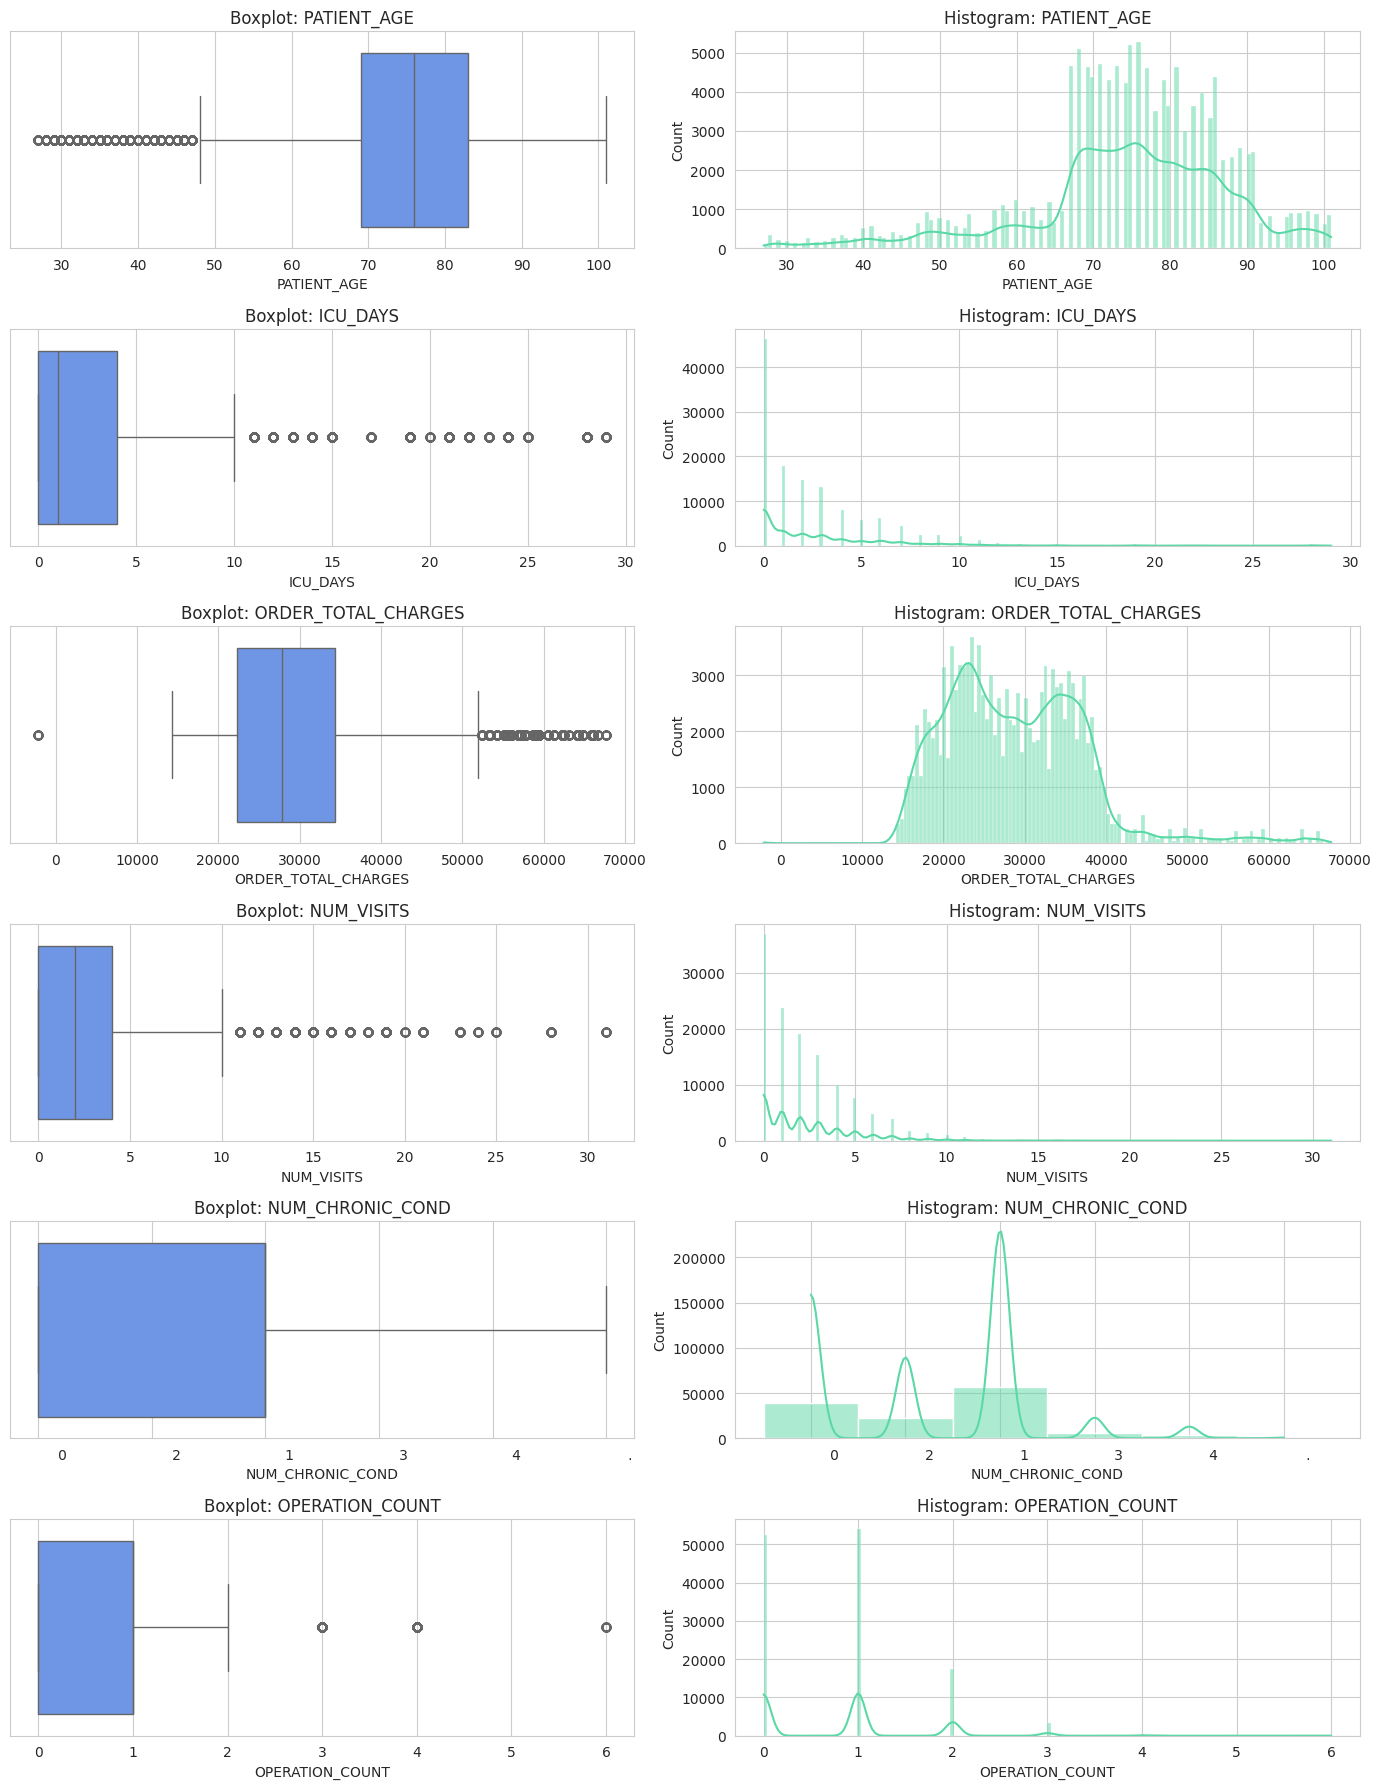

In [7]:
plot_cols = [c for c in candidate_numeric if c in train.columns and c != "ADMIT_LOS"]

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, max(3, 3 * len(plot_cols))))
if len(plot_cols) == 1:
    axes = np.array([axes])

for i, col in enumerate(plot_cols):
    sns.boxplot(x=train[col], ax=axes[i, 0], color="#5B8FF9")
    axes[i, 0].set_title(f"Boxplot: {col}")
    sns.histplot(train[col], kde=True, ax=axes[i, 1], color="#5AD8A6")
    axes[i, 1].set_title(f"Histogram: {col}")

plt.tight_layout()
plt.show()


EDA

count    127802.000000
mean          5.776803
std           4.954379
min           0.000000
25%           3.000000
50%           4.000000
75%           7.000000
max          51.000000
Name: ADMIT_LOS, dtype: float64
Skewness: 2.700258606558056


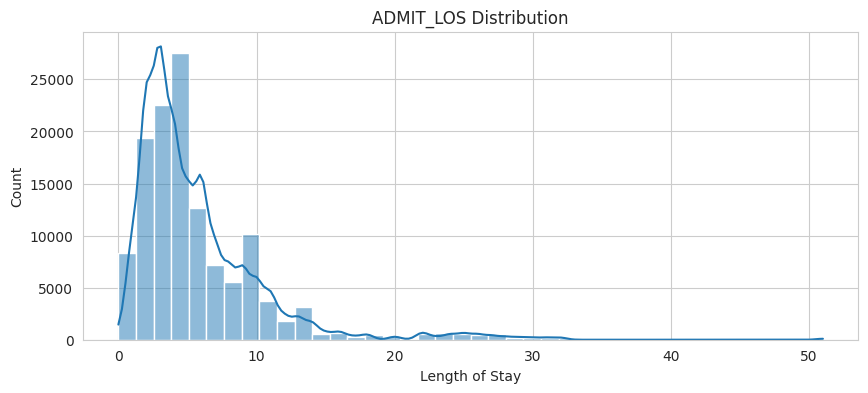

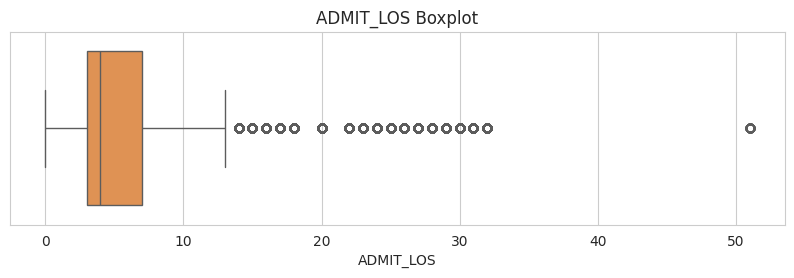

In [8]:
target_col = "ADMIT_LOS"
assert target_col in train.columns, "Target column ADMIT_LOS not found in train.csv"

print(train[target_col].describe())
print("Skewness:", train[target_col].skew())

plt.figure(figsize=(10, 4))
sns.histplot(train[target_col], bins=40, kde=True)
plt.title("ADMIT_LOS Distribution")
plt.xlabel("Length of Stay")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 2.5))
sns.boxplot(x=train[target_col], color="#F6903D")
plt.title("ADMIT_LOS Boxplot")
plt.show()


In [9]:
numeric_cols = train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

display(train[numeric_cols].describe().T.head(20))


Numeric columns: 20
Categorical columns: 25


,count,mean,std,min,25%,50%,75%,max
ENCOUNTER_KEY,127802.0,1.053286e+08,41855.571089,1.052561e+08,1.052923e+08,1.053286e+08,1.053648e+08,1.054011e+08
PATIENT_NUMBER,127802.0,9.921989e+09,41855.571089,9.921916e+09,9.921952e+09,9.921989e+09,9.922025e+09,9.922061e+09
DOCTOR,127802.0,2.680633e+05,37446.361138,2.016200e+05,2.354150e+05,2.620510e+05,2.975010e+05,3.445810e+05
ICU_DAYS,127802.0,2.757359e+00,3.838359,0.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00,2.900000e+01
DISCH_NURSE_ID,127802.0,1.661957e+05,158438.144627,1.001000e+03,1.300500e+04,1.456040e+05,3.200130e+05,8.272980e+05
ORDER_SET_USED,127802.0,8.018497e-01,0.398608,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ORDER_TOTAL_CHARGES,127802.0,2.872260e+04,8476.137908,-2.104000e+03,2.230600e+04,2.783900e+04,3.436800e+04,6.767100e+04
ZIP,127802.0,3.398725e+04,5296.116684,2.215000e+04,3.316100e+04,3.344400e+04,3.345500e+04,7.821900e+04
X,127802.0,-8.108124e+01,2.433185,-9.838098e+01,-8.063284e+01,-8.021644e+01,-8.014331e+01,-7.705166e+01
Y,127802.0,2.751357e+01,2.375456,2.552688e+01,2.645157e+01,2.660693e+01,2.753291e+01,4.198912e+01


In [10]:
for col in [c for c in ["DEPARTMENT", "HOSPITAL", "REGION", "GENDER", "DISCHARGED_TO"] if c in train.columns]:
    print(f"\n{col}: {train[col].nunique(dropna=False)} unique values")
    display(train[col].value_counts(dropna=False).head(10))



DEPARTMENT: 10 unique values


DEPARTMENT
HEART            69597
GENERAL MED      26235
Hosp 46          10236
ONCOLOGY          9423
TRANSPLANT        7591
Hosp 39           3475
NEUROSCIENCES      552
GENERAL SURG       345
WOMENS             307
PSYCH               41
Name: count, dtype: int64


HOSPITAL: 39 unique values


HOSPITAL
Hosp 12    3462
Hosp 36    3461
Hosp 35    3442
Hosp 17    3408
Hosp 16    3402
Hosp 26    3389
Hosp 21    3386
Hosp 4     3370
Hosp 13    3368
Hosp 28    3365
Name: count, dtype: int64


REGION: 11 unique values


REGION
Region 11    21671
Region 8     19855
Region 3     16384
Region 9     13066
Region 6     10036
Region 2     10034
Region 5      9965
Region 1      9914
Region 4      6830
Region 7      6692
Name: count, dtype: int64


GENDER: 2 unique values


GENDER
F    72408
M    55394
Name: count, dtype: int64


DISCHARGED_TO: 11 unique values


DISCHARGED_TO
ROUTINE DSCHG, HOME      80143
HOME HEALTH AGENCY       22506
SKILLED NURSING FACIL    14200
OTHER DEATH               4443
HOSPICE (HOME)            2456
INTERMEDIATE CARE         1770
AGNST MEDICAL ADVICE      1068
CHG TO LTAC                511
OTHER ACUTE HOSP           399
REHAB HOSPITAL             174
Name: count, dtype: int64

Preprocessing



In [11]:
# ==========================================================
# Feature Selection & Preparation
# ==========================================================

# Keep ENCOUNTER_KEY separately for the final submission
id_col = "ENCOUNTER_KEY" if "ENCOUNTER_KEY" in train.columns else None

# ----------------------------------------------------------
# Create working copies
# ----------------------------------------------------------

feature_train = train.copy()
feature_test = test.copy()

# ----------------------------------------------------------
# Remove leakage-prone columns
#
# DISCHARGE_DATE:
#   Used to calculate Length of Stay.
#
# DISCHARGED_TO:
#   Represents the patient's discharge outcome, which is
#   generally only known at the end of the hospital stay.
# ----------------------------------------------------------

drop_cols = [
    c for c in [
        "DISCHARGE_DATE",
        "DISCHARGED_TO",
    ]
    if c in feature_train.columns
]

feature_train.drop(columns=drop_cols, inplace=True, errors="ignore")
feature_test.drop(columns=drop_cols, inplace=True, errors="ignore")

print("Removed leakage-prone columns:", drop_cols)

# ----------------------------------------------------------
# Date Feature Extraction
# ----------------------------------------------------------

for df in [feature_train, feature_test]:

    if "ADMIT_DATE" in df.columns:

        df["ADMIT_DATE"] = pd.to_datetime(
            df["ADMIT_DATE"],
            errors="coerce"
        )

        df["ADMIT_MONTH"] = df["ADMIT_DATE"].dt.month
        df["ADMIT_DAYOFWEEK"] = df["ADMIT_DATE"].dt.dayofweek

        df.drop(columns="ADMIT_DATE", inplace=True)

# ----------------------------------------------------------
# Remove Identifier Columns
# ----------------------------------------------------------

identifier_columns = [
    c for c in [
        "ENCOUNTER_KEY",
        "PATIENT_NUMBER",
        "DOCTOR",
        "DISCH_NURSE_ID",
    ]
    if c in feature_train.columns
]

print("Removed identifier columns:", identifier_columns)

# ----------------------------------------------------------
# Feature / Target Split
# ----------------------------------------------------------

X = feature_train.drop(
    columns=[target_col] + identifier_columns,
    errors="ignore",
)

y = feature_train[target_col].copy()

X_test_full = feature_test.drop(
    columns=identifier_columns,
    errors="ignore",
)

# ----------------------------------------------------------
# Ensure identical feature sets
# ----------------------------------------------------------

common_cols = sorted(
    set(X.columns).intersection(X_test_full.columns)
)

X = X[common_cols]
X_test_full = X_test_full[common_cols]

# ----------------------------------------------------------
# Final Summary
# ----------------------------------------------------------

print("\nFeature matrix shape :", X.shape)
print("Test feature shape   :", X_test_full.shape)

print("\nTotal Features Used:", len(X.columns))

Removed leakage-prone columns: ['DISCHARGE_DATE', 'DISCHARGED_TO']
Removed identifier columns: ['ENCOUNTER_KEY', 'PATIENT_NUMBER', 'DOCTOR', 'DISCH_NURSE_ID']

Feature matrix shape : (127802, 37)
Test feature shape   : (14200, 37)

Total Features Used: 37


In [12]:
# 80/20 split for a simple and beginner-friendly validation setup
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)


X_train: (102241, 37)
X_val  : (25561, 37)
y_train: (102241,)
y_val  : (25561,)


In [13]:
# Split into numeric and categorical columns based on the training set
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", len(num_features))
print("Categorical features:", len(cat_features))

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_features),
    ],
    remainder="drop",
)


Numeric features: 15
Categorical features: 22


In [14]:
print("=" * 60)
print("Feature Leakage Check")
print("=" * 60)

print(f"ADMIT_LOS in X            : {'ADMIT_LOS' in X.columns}")
print(f"ADMIT_DATE in X          : {'ADMIT_DATE' in X.columns}")
print(f"DISCHARGE_DATE in X      : {'DISCHARGE_DATE' in X.columns}")
print(f"ENCOUNTER_KEY in X       : {'ENCOUNTER_KEY' in X.columns}")
print(f"PATIENT_NUMBER in X      : {'PATIENT_NUMBER' in X.columns}")

print("\nNumber of Features:", len(X.columns))

print("\nFeature List:")
for col in X.columns:
    print(col)

Feature Leakage Check
ADMIT_LOS in X            : False
ADMIT_DATE in X          : False
DISCHARGE_DATE in X      : False
ENCOUNTER_KEY in X       : False
PATIENT_NUMBER in X      : False

Number of Features: 37

Feature List:
ADMIT_MTH
CITY
COUNTY_NAME
DEPARTMENT
DIAGNOSIS_GROUP
DIAGNOSIS_ICD_CODE
DIAGNOSIS_LONG_DESC
DIAGNOSIS_SUBCAT_CODE
DIAGNOSIS_SUBCAT_DESC
DRG_APR_CODE
DRG_APR_DESC
DRG_APR_SEVERITY
DX_CODE
DX_GROUP
GENDER
HOSPITAL
ICD9_TARGET
ICU_DAYS
MS_DRG_CODE
MS_DRG_DESC
NUM_CHRONIC_COND
NUM_VISITS
OPERATION_COUNT
ORDER_SET_USED
ORDER_TOTAL_CHARGES
PATIENT_AGE
PROCEDURE_ICD_CODE
PROCEDURE_LONG_DESC
PROCEDURE_SUBCAT_CODE
PROCEDURE_SUBCAT_DESC
RACE_CD
REGION
STANDARD_ORDERS_USED
STATECODE
X
Y
ZIP


Selecting Model

In [15]:


def evaluate_regression_model(
    name,
    framework,
    model,
    X_train,
    y_train,
    X_val,
    y_val,
):

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model),
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    predictions = pipe.predict(X_val)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    mae = mean_absolute_error(y_val, predictions)
    r2 = r2_score(y_val, predictions)

    return {
        "Framework": framework,
        "Model": name,
        "Pipeline": pipe,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
    }

# Candidate Models


sas_models = {

    "Linear Regression": SASLinearRegression(),

    "Ridge": SASRidge(),

    "Forest Regressor": SASForestRegressor()

}


# scikit-learn Baselines
# sklearn_models = {

#     "Random Forest":
#         RandomForestRegressor(
#             n_estimators=200,
#             random_state=42,
#             n_jobs=-1,
#         ),

#     "Extra Trees":
#         ExtraTreesRegressor(
#             n_estimators=200,
#             random_state=42,
#             n_jobs=-1,
#         ),

#     "HistGradientBoosting":
#         HistGradientBoostingRegressor(
#             random_state=42,
#         ),
# }


# Benchmark

results = []
fitted_pipelines = {}

print("=" * 70)
print("MODEL BENCHMARKING")
print("=" * 70)


# SAS Models

print("\nBenchmarking SAS Viya Models...\n")

for name, model in sas_models.items():

    try:

        output = evaluate_regression_model(
            name=name,
            framework="SAS Viya",
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
        )

        results.append({
            k: v
            for k, v in output.items()
            if k != "Pipeline"
        })

        fitted_pipelines[
            f"SAS Viya - {name}"
        ] = output["Pipeline"]

        print(
            f"✅ {name:<20}"
            f" RMSE={output['RMSE']:.4f}"
            f" | MAE={output['MAE']:.4f}"
            f" | R²={output['R²']:.4f}"
        )

    except Exception as e:

        print(f"❌ {name}")
        print(f"   {e}")

# scikit-learn Baselines

# print("\nBenchmarking scikit-learn Models...\n")

# for name, model in sklearn_models.items():

#     try:

#         output = evaluate_regression_model(
#             name=name,
#             framework="scikit-learn",
#             model=model,
#             X_train=X_train,
#             y_train=y_train,
#             X_val=X_val,
#             y_val=y_val,
#         )

#         results.append({
#             k: v
#             for k, v in output.items()
#             if k != "Pipeline"
#         })

#         fitted_pipelines[
#             f"scikit-learn - {name}"
#         ] = output["Pipeline"]

#         print(
#             f"✅ {name:<20}"
#             f" RMSE={output['RMSE']:.4f}"
#             f" | MAE={output['MAE']:.4f}"
#             f" | R²={output['R²']:.4f}"
#         )

#     except Exception as e:

#         print(f"❌ {name}")
#         print(f"   {e}")


# Results

results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

results_df.index += 1
results_df.index.name = "Rank"

results_df = results_df.round(4)

print("\n")
print("=" * 70)
print("MODEL PERFORMANCE (Ranked by RMSE)")
print("=" * 70)

display(results_df)


# Best Model

best_model_info = results_df.iloc[0]

print("\n🏆 Best Model Selected")
print("-" * 40)

print(f"Framework : {best_model_info['Framework']}")
print(f"Model      : {best_model_info['Model']}")
print(f"RMSE       : {best_model_info['RMSE']:.4f}")
print(f"MAE        : {best_model_info['MAE']:.4f}")
print(f"R²         : {best_model_info['R²']:.4f}")

MODEL BENCHMARKING

Benchmarking SAS Viya Models...



✅ Linear Regression    RMSE=3.1898 | MAE=1.9386 | R²=0.5879
✅ Ridge                RMSE=3.1935 | MAE=1.9365 | R²=0.5870
✅ Forest Regressor     RMSE=1.6698 | MAE=1.1862 | R²=0.8871


MODEL PERFORMANCE (Ranked by RMSE)


,Framework,Model,RMSE,MAE,R²
Rank,,,,,
1,SAS Viya,Forest Regressor,1.6698,1.1862,0.8871
2,SAS Viya,Linear Regression,3.1898,1.9386,0.5879
3,SAS Viya,Ridge,3.1935,1.9365,0.5870



🏆 Best Model Selected
----------------------------------------
Framework : SAS Viya
Model      : Forest Regressor
RMSE       : 1.6698
MAE        : 1.1862
R²         : 0.8871


In [16]:
results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

results_df.index += 1
results_df.index.name = "Rank"

display(results_df.round(4))

print("=" * 50)
print("🏆 Best Model")
print("=" * 50)

print(f"Framework : {best_model['Framework']}")
print(f"Model     : {best_model['Model']}")
print(f"RMSE      : {best_model['RMSE']:.4f}")
print(f"MAE       : {best_model['MAE']:.4f}")
print(f"R²        : {best_model['R²']:.4f}")

,Framework,Model,RMSE,MAE,R²
Rank,,,,,
1,SAS Viya,Forest Regressor,1.6698,1.1862,0.8871
2,SAS Viya,Linear Regression,3.1898,1.9386,0.5879
3,SAS Viya,Ridge,3.1935,1.9365,0.5870


🏆 Best Model


NameError: name 'best_model' is not defined

Final Model

In [17]:
selected_model = "SAS Viya - Forest Regressor"

best_pipeline = fitted_pipelines[selected_model]

print("=" * 60)
print("Final Model Selected")
print("=" * 60)
print(selected_model)

print("\nTraining best model using the full training dataset...")

best_pipeline.fit(X, y)

print("Generating predictions...")

predictions = best_pipeline.predict(X_test_full)

# Prevent impossible negative LOS values
predictions = np.clip(predictions, 0, None)

submission = pd.DataFrame({
    "ENCOUNTER_KEY": test["ENCOUNTER_KEY"],
    "ADMIT_LOS": predictions
})

# Validation
assert len(submission) == len(test)
assert list(submission.columns) == [
    "ENCOUNTER_KEY",
    "ADMIT_LOS"
]
assert submission["ADMIT_LOS"].notna().all()
assert submission["ENCOUNTER_KEY"].is_unique

submission.to_csv("submission.csv", index=False)
assert list(submission.columns) == ["ENCOUNTER_KEY", "ADMIT_LOS"]
print("\n✅ submission.csv generated successfully!")

display(submission.head())

Final Model Selected
SAS Viya - Forest Regressor

Training best model using the full training dataset...
Generating predictions...

✅ submission.csv generated successfully!


,ENCOUNTER_KEY,ADMIT_LOS
0,105256127,4.663908
1,105256137,2.589457
2,105256138,2.664081
3,105256139,3.798042
4,105256195,4.120002


In [18]:
results_df.to_csv("model_results.csv", index=False)